In [1]:
# ==========================================
# CELL 1: IMPORT & PENGGABUNGAN DATA
# ==========================================
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Set style grafik agar elegan untuk skripsi
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# 1. Daftar File (Sesuaikan path jika file berada di dalam folder tertentu, misal 'results/')
PATH = '../data/results/' # Isi './results/' jika file ada di dalam folder results
file_overall = [
    PATH + 'skenario1_overall_nmt_vs_llm.csv',
    PATH + 'skenario2_distilbert_evaluasi_overall.csv',
    PATH + 'skenario2_mmbert-small_evaluasi_overall.csv',
    PATH + 'skenario2_mmbert-base_evaluasi_overall.csv',
    PATH + 'skenario3_overall_nmt_vs_llm.csv'
]
file_tipe = [
    PATH + 'skenario1_tipe_kueri_nmt_vs_llm.csv',
    PATH + 'skenario2_distilbert_evaluasi_tipe_kueri.csv',
    PATH + 'skenario2_mmbert-small_evaluasi_tipe_kueri.csv',
    PATH + 'skenario2_mmbert-base_evaluasi_tipe_kueri.csv',
    PATH + 'skenario3_tipe_kueri_nmt_vs_llm.csv'
]
file_detail = [
    PATH + 'skenario1_detail_per_kueri_nmt_vs_llm.csv',
    PATH + 'skenario2_distilbert_detail_per_kueri.csv',
    PATH + 'skenario2_mmbert-small_detail_per_kueri.csv',
    PATH + 'skenario2_mmbert-base_detail_per_kueri.csv',
    PATH + 'skenario3_detail_per_kueri_nmt_vs_llm.csv'
]

# 2. Fungsi Penggabungan
def gabung_csv(list_file):
    df_list = []
    for file in list_file:
        if os.path.exists(file):
            df = pd.read_csv(file)
            if 'skenario1' in file:
                df.insert(0, 'Skenario', '1. BM25 (Sparse)')
            elif 'skenario2' in file:
                df.insert(0, 'Skenario', '2. Cross-Lingual (Dense)')
            elif 'skenario3' in file:
                df.insert(0, 'Skenario', '3. AraDPR (Monolingual)')
            df_list.append(df)
        else:
            print(f"⚠️ File tidak ditemukan: {file}")
            
    return pd.concat(df_list, ignore_index=True) if df_list else pd.DataFrame()

print("Membaca dan menggabungkan data...")
df_overall = gabung_csv(file_overall)
df_tipe = gabung_csv(file_tipe)
df_detail = gabung_csv(file_detail)

print(f"✅ Data Overall: {len(df_overall)} model")
print(f"✅ Data Per Tipe: {len(df_tipe)} baris")
print(f"✅ Data Detail : {len(df_detail)} baris")

Membaca dan menggabungkan data...
✅ Data Overall: 12 model
✅ Data Per Tipe: 36 baris
✅ Data Detail : 1836 baris


🏆 KLASEMEN MODEL TERBAIK (Diurutkan berdasarkan Hits@10)


,Skenario,name,recip_rank,success_10 (%),success_20 (%)
0,1. BM25 (Sparse),BM25+RM3 (Gemini LLM),0.3602,56.86,66.67
1,1. BM25 (Sparse),BM25 (Gemini LLM),0.3568,56.21,65.36
2,2. Cross-Lingual (Dense),mmBERT-base Fine-Tuned (JH-POLO),0.2976,50.98,59.48
3,2. Cross-Lingual (Dense),mmBERT-small Fine-Tuned (JH-POLO),0.2590,41.83,49.67
4,2. Cross-Lingual (Dense),DistilBERT Base Fine-Tuned (JH-POLO),0.1853,35.29,45.75
5,1. BM25 (Sparse),BM25+RM3 (Google NMT),0.1586,30.72,40.52
6,3. AraDPR (Monolingual),AraDPR (Gemini LLM),0.1437,28.76,37.91
7,1. BM25 (Sparse),BM25 (Google NMT),0.1562,26.80,33.99
8,3. AraDPR (Monolingual),AraDPR (Google NMT),0.0685,17.65,28.76
9,2. Cross-Lingual (Dense),Baseline (DistilBERT Base),0.0149,1.96,5.88


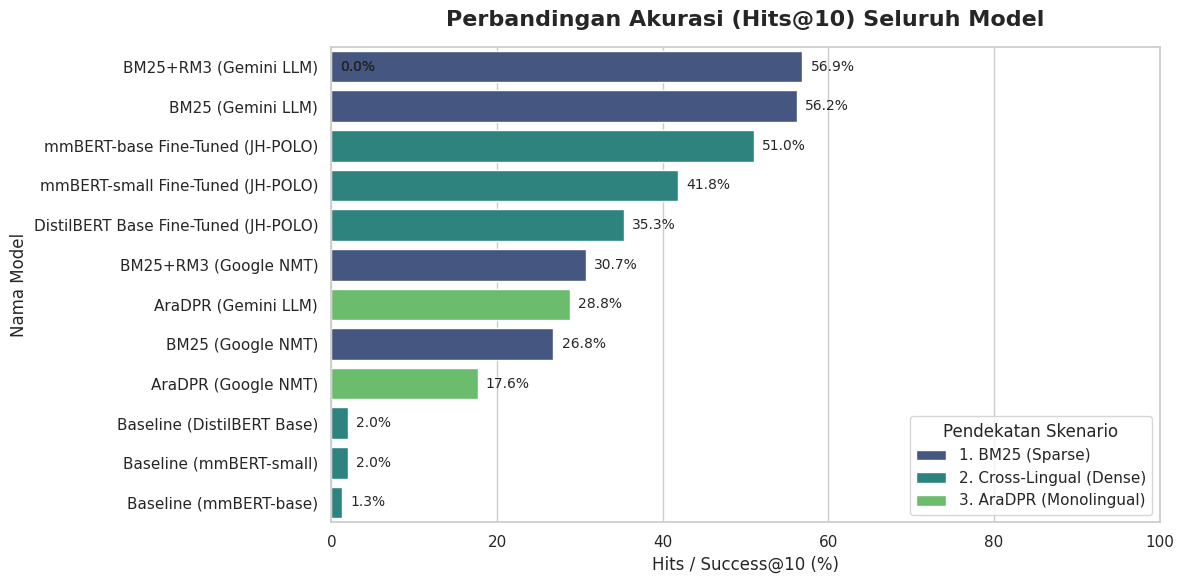

📊 Grafik berhasil disimpan sebagai 'grafik_overall_hits10.png'


In [2]:
# ==========================================
# CELL 2: PERINGKAT KESELURUHAN (OVERALL RANKING)
# ==========================================
print("🏆 KLASEMEN MODEL TERBAIK (Diurutkan berdasarkan Hits@10)")

# Mengurutkan dari nilai terbesar ke terkecil
df_overall_sorted = df_overall.sort_values(by='success_10 (%)', ascending=False).reset_index(drop=True)
display(df_overall_sorted[['Skenario', 'name', 'recip_rank', 'success_10 (%)', 'success_20 (%)']])

# --- MEMBUAT VISUALISASI GRAFIK BAR ---
plt.figure(figsize=(12, 6))

# Kita visualisasikan Success@10 (Hits@10)
ax = sns.barplot(
    data=df_overall_sorted, 
    x='success_10 (%)', 
    y='name', 
    hue='Skenario',
    dodge=False, # Agar bar tidak tumpang tindih
    palette='viridis'
)

plt.title('Perbandingan Akurasi (Hits@10) Seluruh Model', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Hits / Success@10 (%)', fontsize=12)
plt.ylabel('Nama Model', fontsize=12)
plt.xlim(0, 100) # Persentase maksimal 100%

# Menambahkan angka di sebelah ujung bar
for p in ax.patches:
    width = p.get_width()
    if pd.isna(width): continue
    plt.text(width + 1, p.get_y() + p.get_height()/2, f'{width:.1f}%', va='center', fontsize=10)

plt.legend(title='Pendekatan Skenario', loc='lower right')
plt.tight_layout()
plt.savefig('grafik_overall_hits10.png', dpi=300)
plt.show()
print("📊 Grafik berhasil disimpan sebagai 'grafik_overall_hits10.png'")

📊 MATRIKS HITS@20 BERDASARKAN TIPE KUERI


,Skenario,name,Tipe 1 (Kata Kunci),Tipe 2 (Tanya Awam),Tipe 3 (Studi Kasus)
0,1. BM25 (Sparse),BM25 (Gemini LLM),68.63,60.78,39.22
1,1. BM25 (Sparse),BM25 (Google NMT),35.29,23.53,21.57
2,1. BM25 (Sparse),BM25+RM3 (Gemini LLM),70.59,62.75,37.25
3,1. BM25 (Sparse),BM25+RM3 (Google NMT),41.18,29.41,21.57
4,2. Cross-Lingual (Dense),Baseline (DistilBERT Base),1.96,0.00,3.92
5,2. Cross-Lingual (Dense),Baseline (mmBERT-base),1.96,1.96,0.00
6,2. Cross-Lingual (Dense),Baseline (mmBERT-small),0.00,3.92,1.96
7,2. Cross-Lingual (Dense),DistilBERT Base Fine-Tuned (JH-POLO),35.29,35.29,35.29
8,2. Cross-Lingual (Dense),mmBERT-base Fine-Tuned (JH-POLO),41.18,54.90,56.86
9,2. Cross-Lingual (Dense),mmBERT-small Fine-Tuned (JH-POLO),39.22,49.02,37.25


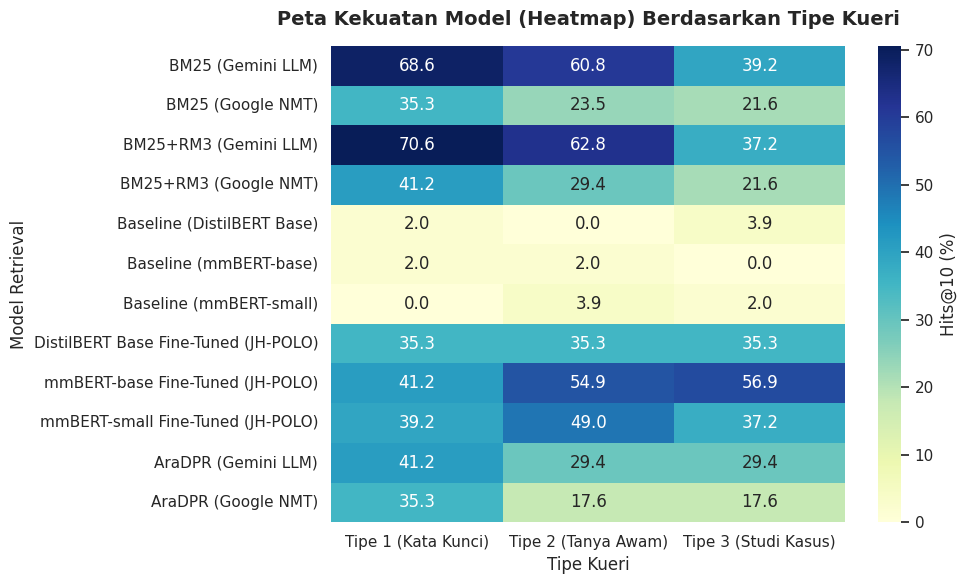

🔥 Heatmap berhasil disimpan sebagai 'grafik_heatmap_tipe_kueri.png'


In [3]:
# ==========================================
# CELL 3: ANALISIS KEKUATAN PER TIPE KUERI
# ==========================================
print("📊 MATRIKS HITS@20 BERDASARKAN TIPE KUERI")

# Membuat tabel pivot agar Tipe Kueri menjadi kolom di atas
pivot_tipe = df_tipe.pivot_table(
    index=['Skenario', 'name'], 
    columns='query_type', 
    values='success_10 (%)'
).reset_index()

# Merapikan nama kolom
pivot_tipe.columns.name = None
pivot_tipe = pivot_tipe.rename(columns={
    1: 'Tipe 1 (Kata Kunci)', 
    2: 'Tipe 2 (Tanya Awam)', 
    3: 'Tipe 3 (Studi Kasus)'
})

# Urutkan berdasarkan performa Skenario
pivot_tipe = pivot_tipe.sort_values(by=['Skenario', 'name'])
display(pivot_tipe)

# --- VISUALISASI HEATMAP (SANGAT ELEGAN UNTUK SKRIPSI) ---
plt.figure(figsize=(10, 6))
# Ambil data angkanya saja untuk heatmap
heatmap_data = pivot_tipe.set_index('name')[['Tipe 1 (Kata Kunci)', 'Tipe 2 (Tanya Awam)', 'Tipe 3 (Studi Kasus)']]

sns.heatmap(
    heatmap_data, 
    annot=True,      # Tampilkan angka
    fmt=".1f",       # 1 angka di belakang koma
    cmap="YlGnBu",   # Skala warna Biru-Hijau
    cbar_kws={'label': 'Hits@10 (%)'}
)

plt.title('Peta Kekuatan Model (Heatmap) Berdasarkan Tipe Kueri', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Model Retrieval')
plt.xlabel('Tipe Kueri')
plt.tight_layout()
plt.savefig('grafik_heatmap_tipe_kueri.png', dpi=300)
plt.show()
print("🔥 Heatmap berhasil disimpan sebagai 'grafik_heatmap_tipe_kueri.png'")

In [4]:
# ==========================================
# CELL 4: AUTOMATIC CASE STUDY FINDER
# ==========================================
print("🔍 MENCARI BUKTI KASUS UNTUK BAB 4")

# Kita pivot df_detail agar setiap model memiliki kolom 'Hit@20'-nya sendiri
detail_pivot = df_detail.pivot_table(
    index=['qid', 'query_type', 'query'],
    columns='name',
    values='Hit@20',
    aggfunc='first'
).reset_index()

# ------------- KASUS 1: EFEK FINE-TUNING (JH-POLO) -------------
# Mencari kueri di mana mmBERT-Base gagal, tapi setelah Fine-Tuned (JH-POLO) dia berhasil
if 'Baseline (mmBERT Base)' in detail_pivot.columns and 'Fine-Tuned mmBERT-Base (JH-POLO)' in detail_pivot.columns:
    kasus_finetuning = detail_pivot[
        (detail_pivot['Baseline (mmBERT Base)'] == '❌ Miss') & 
        (detail_pivot['Fine-Tuned mmBERT-Base (JH-POLO)'] == '✅ Hit')
    ]
    
    print("\n" + "="*70)
    print("🌟 KASUS 1: Kueri yang BERHASIL dijawab berkat Fine-Tuning JH-POLO")
    print("="*70)
    display(kasus_finetuning[['qid', 'query_type', 'query', 'Baseline (mmBERT Base)', 'Fine-Tuned mmBERT-Base (JH-POLO)']].head(5))

# ------------- KASUS 2: LLM vs NMT (Skenario 1) -------------
# Mencari kueri di mana Google NMT gagal, tapi Gemini LLM berhasil (BM25)
if 'BM25 (Google NMT)' in detail_pivot.columns and 'BM25 (Gemini LLM)' in detail_pivot.columns:
    kasus_terjemahan = detail_pivot[
        (detail_pivot['BM25 (Google NMT)'] == '❌ Miss') & 
        (detail_pivot['BM25 (Gemini LLM)'] == '✅ Hit')
    ]
    
    print("\n" + "="*70)
    print("🌟 KASUS 2: Kueri yang BERHASIL dijawab karena terjemahan Gemini LLM lebih baik")
    print("="*70)
    display(kasus_terjemahan[['qid', 'query_type', 'query', 'BM25 (Google NMT)', 'BM25 (Gemini LLM)']].head(5))

🔍 MENCARI BUKTI KASUS UNTUK BAB 4

🌟 KASUS 2: Kueri yang BERHASIL dijawab karena terjemahan Gemini LLM lebih baik


name,qid,query_type,query,BM25 (Google NMT),BM25 (Gemini LLM)
9,5,2.0,Bagaimana hukum membaca basmalah di tengah-ten...,❌ Miss,✅ Hit
17,9,3.0,Siti merupakan pasien penderita penyakit wasir...,❌ Miss,✅ Hit
25,13,1.0,Tata cara mensucikan najis (air seni) yang tel...,❌ Miss,✅ Hit
28,15,3.0,Nabila merupakan seorang pecinta kucing. Kecin...,❌ Miss,✅ Hit
30,16,1.0,Kewajiban mengingatkan seseorang yang pakaiann...,❌ Miss,✅ Hit


In [5]:
# ==========================================
# CELL 5: EXPORT HITS@10 PER QUERY PER MODEL KE CSV
# ==========================================
print("📊 EXPORT HITS@10 (Success@10) UNTUK SETIAP QUERY DAN MODEL")

# 1. Baca daftar kueri dari queries_indo.csv (153 kueri)
queries_file = '../data/queries/queries_indo.csv'
df_queries = pd.read_csv(queries_file)
print(f"✅ Loaded {len(df_queries)} queries dari queries_indo.csv")
print(f"   Query types: {sorted(df_queries['query_type'].unique())}")

# 2. Pivot df_detail untuk membuat setiap model menjadi kolom
df_detail['Hit@10_numeric'] = df_detail['Hit@10'].map({'✅ Hit': 1, '❌ Miss': 0})

detail_pivot = df_detail.pivot_table(
    index='qid',
    columns='name',
    values='Hit@10_numeric',
    aggfunc='first'
).reset_index()

print(f"✅ Pivot table: {len(detail_pivot)} rows, {len(detail_pivot.columns)} columns")

# 3. Merge dengan queries untuk dapatkan query_type dan urutan yang benar
result = df_queries[['qid', 'query', 'query_type']].merge(
    detail_pivot,
    on='qid',
    how='left'
)

# 4. Rename kolom model
model_cols = []
for col in result.columns:
    if col not in ['qid', 'query', 'query_type']:
        new_name = f"{col} (Hits@10)"
        result = result.rename(columns={col: new_name})
        model_cols.append(new_name)

# 5. Reorder kolom
result = result[['qid', 'query', 'query_type'] + model_cols]

print(f"\n=== HASIL AKHIR ===")
print(f"Total rows: {len(result)}")
print(f"Total columns: {len(result.columns)}")

# Check nulls
null_counts = result.isnull().sum()
if null_counts.sum() > 0:
    print(f"\n⚠️ Ada nilai null!")
else:
    print(f"\n✅ Tidak ada nilai null")

# Preview
print(f"\n📋 Sample data:")
display(result[['qid', 'query_type'] + model_cols[:3]].head())

# Export
output_file = 'query_hits10_per_model.csv'
result.to_csv(output_file, index=False)
print(f"\n💾 Saved to: {output_file}")

print(f"\n📊 Total model: {len(model_cols)}")

📊 EXPORT HITS@10 (Success@10) UNTUK SETIAP QUERY DAN MODEL
✅ Loaded 153 queries dari queries_indo.csv
   Query types: [1, 2, 3]
✅ Pivot table: 153 rows, 13 columns

=== HASIL AKHIR ===
Total rows: 153
Total columns: 15

✅ Tidak ada nilai null

📋 Sample data:


,qid,query_type,AraDPR (Gemini LLM) (Hits@10),AraDPR (Google NMT) (Hits@10),BM25 (Gemini LLM) (Hits@10)
0,1,1,1,0,1
1,2,2,0,0,0
2,3,3,0,0,0
3,4,1,0,0,0
4,5,2,0,0,1



💾 Saved to: query_hits10_per_model.csv

📊 Total model: 12


In [6]:
# ==========================================
# CELL 6: ANALISIS KOMPARATIF MODEL - QUERY ANALYSIS TOOLS
# ==========================================

# Reload data fresh untuk analisis
queries_file = '../data/queries/queries_indo.csv'
df_queries = pd.read_csv(queries_file)

# Recreate result dataframe dari Cell 5
df_detail['Hit@10_numeric'] = df_detail['Hit@10'].map({'✅ Hit': 1, '❌ Miss': 0})
detail_pivot = df_detail.pivot_table(
    index='qid',
    columns='name',
    values='Hit@10_numeric',
    aggfunc='first'
).reset_index()

result = df_queries[['qid', 'query', 'query_type']].merge(
    detail_pivot, on='qid', how='left'
)

# Simpan nama kolom model (tanpa suffix)
model_names = [c for c in result.columns if c not in ['qid', 'query', 'query_type']]
print(f"📊 Model tersedia untuk analisis ({len(model_names)}):")
for i, m in enumerate(model_names, 1):
    print(f"   {i}. {m}")

# =============================================================================
# FUNGSI 1: Query yang HANYA ditemukan oleh model tertentu (UNIQUE HITS)
# =============================================================================
def find_unique_to_model(target_model, result_df, model_cols):
    """
    Temukan query yang hanya berhasil ditemukan oleh target_model,
    tapi TIDAK ditemukan oleh model lainnya.
    """
    if target_model not in model_cols:
        print(f"❌ Model '{target_model}' tidak ditemukan!")
        return None
    
    other_models = [m for m in model_cols if m != target_model]
    
    # Kondisi: target_model = 1, semua model lain = 0
    condition = (result_df[target_model] == 1)
    for m in other_models:
        condition = condition & (result_df[m] == 0)
    
    unique_queries = result_df[condition][['qid', 'query', 'query_type', target_model]]
    return unique_queries

# =============================================================================
# FUNGSI 2: Query yang ditemukan oleh SEMUA model
# =============================================================================
def find_queries_all_models_hit(result_df, model_cols):
    """
    Temukan query yang berhasil ditemukan oleh SEMUA model (semua = 1).
    """
    condition = (result_df[model_cols[0]] == 1)
    for m in model_cols[1:]:
        condition = condition & (result_df[m] == 1)
    
    all_hit = result_df[condition][['qid', 'query', 'query_type'] + model_cols]
    return all_hit

# =============================================================================
# FUNGSI 3: Query yang TIDAK ditemukan oleh SEMUA model
# =============================================================================
def find_queries_all_models_miss(result_df, model_cols):
    """
    Temukan query yang gagal ditemukan oleh SEMUA model (semua = 0).
    """
    condition = (result_df[model_cols[0]] == 0)
    for m in model_cols[1:]:
        condition = condition & (result_df[m] == 0)
    
    all_miss = result_df[condition][['qid', 'query', 'query_type'] + model_cols]
    return all_miss

# =============================================================================
# FUNGSI 4: Query yang ditemukan oleh Model A tapi TIDAK oleh Model B
# =============================================================================
def compare_two_models(model_a, model_b, result_df, model_cols):
    """
    Temukan query yang:
    - Berhasil ditemukan oleh Model A (hit)
    - Gagal ditemukan oleh Model B (miss)
    """
    if model_a not in model_cols or model_b not in model_cols:
        print(f"❌ Salah satu model tidak ditemukan!")
        return None
    
    condition = (result_df[model_a] == 1) & (result_df[model_b] == 0)
    comparison = result_df[condition][['qid', 'query', 'query_type', model_a, model_b]]
    return comparison

# =============================================================================
# FUNGSI 5: Hit Rate Summary per Model
# =============================================================================
def hit_rate_summary(result_df, model_cols):
    """
    Buat summary hit rate untuk setiap model.
    """
    summary = []
    for m in model_cols:
        hits = result_df[m].sum()
        total = len(result_df)
        rate = (hits / total) * 100
        summary.append({'Model': m, 'Hits': hits, 'Total': total, 'Hit Rate (%)': round(rate, 2)})
    
    return pd.DataFrame(summary).sort_values('Hit Rate (%)', ascending=False)

# =============================================================================
# FUNGSI 6: Query yang ditemukan oleh subset model tertentu
# =============================================================================
def find_queries_by_models(required_models, result_df, model_cols, mode='any'):
    """
    mode='any': Query ditemukan oleh minimal salah satu dari required_models
    mode='all': Query ditemukan oleh SEMUA required_models
    """
    if not all(m in model_cols for m in required_models):
        missing = [m for m in required_models if m not in model_cols]
        print(f"❌ Model tidak ditemukan: {missing}")
        return None
    
    if mode == 'any':
        condition = (result_df[required_models[0]] == 1)
        for m in required_models[1:]:
            condition = condition | (result_df[m] == 1)
    else:  # mode == 'all'
        condition = (result_df[required_models[0]] == 1)
        for m in required_models[1:]:
            condition = condition & (result_df[m] == 1)
    
    return result_df[condition][['qid', 'query', 'query_type'] + model_cols]

print("\n✅ Semua fungsi analisis siap digunakan!")
print("\n📋 Contoh penggunaan:")
print("   unique_mmBERT = find_unique_to_model('mmBERT-base Fine-Tuned (JH-POLO)', result, model_names)")
print("   all_hit = find_queries_all_models_hit(result, model_names)")
print("   comparison = compare_two_models('BM25 (Gemini LLM)', 'BM25 (Google NMT)', result, model_names)")
print("   summary = hit_rate_summary(result, model_names)")

📊 Model tersedia untuk analisis (12):
   1. AraDPR (Gemini LLM)
   2. AraDPR (Google NMT)
   3. BM25 (Gemini LLM)
   4. BM25 (Google NMT)
   5. BM25+RM3 (Gemini LLM)
   6. BM25+RM3 (Google NMT)
   7. Baseline (DistilBERT Base)
   8. Baseline (mmBERT-base)
   9. Baseline (mmBERT-small)
   10. DistilBERT Base Fine-Tuned (JH-POLO)
   11. mmBERT-base Fine-Tuned (JH-POLO)
   12. mmBERT-small Fine-Tuned (JH-POLO)

✅ Semua fungsi analisis siap digunakan!

📋 Contoh penggunaan:
   unique_mmBERT = find_unique_to_model('mmBERT-base Fine-Tuned (JH-POLO)', result, model_names)
   all_hit = find_queries_all_models_hit(result, model_names)
   comparison = compare_two_models('BM25 (Gemini LLM)', 'BM25 (Google NMT)', result, model_names)
   summary = hit_rate_summary(result, model_names)


In [7]:
# ==========================================
# CELL 7: CONTOH ANALISIS KOMPARATIF
# ==========================================

print("="*70)
print("📊 ANALISIS 1: HIT RATE SUMMARY (Performa Keseluruhan)")
print("="*70)
summary = hit_rate_summary(result, model_names)
display(summary)

print("\n" + "="*70)
print("📊 ANALISIS 2: Query yang HANYA ditemukan oleh mmBERT-base Fine-Tuned")
print("="*70)
unique_mmBERT = find_unique_to_model('mmBERT-base Fine-Tuned (JH-POLO)', result, model_names)
print(f"\n🔍 Ditemukan {len(unique_mmBERT)} query yang HANYA bisa ditemukan oleh mmBERT-base Fine-Tuned:")
if len(unique_mmBERT) > 0:
    display(unique_mmBERT[['qid', 'query_type', 'query']])
else:
    print("   (Tidak ada query yang uniquely ditemukan oleh model ini)")

print("\n" + "="*70)
print("📊 ANALISIS 3: Query yang HANYA ditemukan oleh BM25 + Gemini LLM")
print("="*70)
unique_bm25_gemini = find_unique_to_model('BM25 (Gemini LLM)', result, model_names)
print(f"\n🔍 Ditemukan {len(unique_bm25_gemini)} query yang HANYA bisa ditemukan oleh BM25 (Gemini LLM):")
if len(unique_bm25_gemini) > 0:
    display(unique_bm25_gemini[['qid', 'query_type', 'query']])
else:
    print("   (Tidak ada query yang uniquely ditemukan oleh model ini)")

print("\n" + "="*70)
print("📊 ANALISIS 4: Query yang ditemukan SEMUA model")
print("="*70)
all_hit = find_queries_all_models_hit(result, model_names)
print(f"\n✅ {len(all_hit)} query berhasil ditemukan oleh SEMUA model")
if len(all_hit) > 0:
    display(all_hit[['qid', 'query_type', 'query']].head(10))
    print(f"   ... dan {len(all_hit)-10} query lainnya" if len(all_hit) > 10 else "")

print("\n" + "="*70)
print("📊 ANALISIS 5: Query yang TIDAK ditemukan SEMUA model")
print("="*70)
all_miss = find_queries_all_models_miss(result, model_names)
print(f"\n❌ {len(all_miss)} query gagal ditemukan oleh SEMUA model")
if len(all_miss) > 0:
    display(all_miss[['qid', 'query_type', 'query']])

print("\n" + "="*70)
print("📊 ANALISIS 6: BM25 (Gemini LLM) vs BM25 (Google NMT)")
print("="*70)
gemini_vs_nmt = compare_two_models('BM25 (Gemini LLM)', 'BM25 (Google NMT)', result, model_names)
print(f"\n📌 {len(gemini_vs_nmt)} query ditemukan oleh Gemini LLM tapi TIDAK oleh Google NMT:")
if len(gemini_vs_nmt) > 0:
    display(gemini_vs_nmt[['qid', 'query_type', 'query']].head(10))
    if len(gemini_vs_nmt) > 10:
        print(f"   ... dan {len(gemini_vs_nmt)-10} query lainnya")


📊 ANALISIS 1: HIT RATE SUMMARY (Performa Keseluruhan)


,Model,Hits,Total,Hit Rate (%)
4,BM25+RM3 (Gemini LLM),87,153,56.86
2,BM25 (Gemini LLM),86,153,56.21
10,mmBERT-base Fine-Tuned (JH-POLO),78,153,50.98
11,mmBERT-small Fine-Tuned (JH-POLO),64,153,41.83
9,DistilBERT Base Fine-Tuned (JH-POLO),54,153,35.29
5,BM25+RM3 (Google NMT),47,153,30.72
0,AraDPR (Gemini LLM),44,153,28.76
3,BM25 (Google NMT),41,153,26.80
1,AraDPR (Google NMT),27,153,17.65
6,Baseline (DistilBERT Base),3,153,1.96



📊 ANALISIS 2: Query yang HANYA ditemukan oleh mmBERT-base Fine-Tuned

🔍 Ditemukan 8 query yang HANYA bisa ditemukan oleh mmBERT-base Fine-Tuned:


,qid,query_type,query
11,12,3,Pak Imam merupakan salah seorang yang sangat b...
28,29,2,Apakah hukum melakukan adzan pada selain shola...
62,63,3,"Di dalam kereta api jarak jauh, seorang penump..."
80,81,3,Sekolah SMP Harapan Bangsa menerapkan konsep ...
84,85,1,berhutang untuk maksiat
86,87,3,"sebut saja nama Toni, dia adalah seorang sauda..."
94,95,2,berapa batas maksimal wasiat?
95,96,3,Hasan adalah pengusaha makanan cepat saji yang...



📊 ANALISIS 3: Query yang HANYA ditemukan oleh BM25 + Gemini LLM

🔍 Ditemukan 1 query yang HANYA bisa ditemukan oleh BM25 (Gemini LLM):


...


📊 ANALISIS 4: Query yang ditemukan SEMUA model

✅ 0 query berhasil ditemukan oleh SEMUA model

📊 ANALISIS 5: Query yang TIDAK ditemukan SEMUA model

❌ 14 query gagal ditemukan oleh SEMUA model


,qid,query_type,query
27,28,1,Kesunnahan adzan pada selain sholat fardhu
53,54,3,"Rehan sedang melaksanakan ibadah haji, namun d..."
54,55,1,Syarat-syarat penerima zakat
72,73,1,mabuk perjalanan saat berpuasa
74,75,3,"Karena masih dalam masa pengantin baru, Mas Ji..."
77,78,3,Dana dan Dono adalah kakak beradik yang usian...
82,83,2,apa hukum membeli barang yang belum pernah dil...
89,90,3,"karena pertumbuhan penduduk sangat cepat, sebu..."
98,99,3,Rahmat sedang mendatangi acara walimah saudara...
116,117,3,Seorang perempuan baru saja menikah namun dia ...



📊 ANALISIS 6: BM25 (Gemini LLM) vs BM25 (Google NMT)

📌 50 query ditemukan oleh Gemini LLM tapi TIDAK oleh Google NMT:


,qid,query_type,query
0,1,1,Kewajiban orang tua untuk memerintahkan sholat...
4,5,2,Bagaimana hukum membaca basmalah di tengah-ten...
8,9,3,Siti merupakan pasien penderita penyakit wasir...
12,13,1,Tata cara mensucikan najis (air seni) yang tel...
14,15,3,Nabila merupakan seorang pecinta kucing. Kecin...
15,16,1,Kewajiban mengingatkan seseorang yang pakaiann...
16,17,2,Bagaiamana hukum mengingatkan seseorang yang h...
17,18,3,"Suatu ketka, saat Mas Agil ingin melaksanakan ..."
24,25,1,Hukum melakukan sunnah ab'ad yang terlupakan s...
25,26,2,Bagaimana hukum kembali melakukan tasyahud awa...


   ... dan 40 query lainnya


In [8]:
# ==========================================
# CELL 8: ANALISIS LANJUTAN - BY QUERY TYPE & HEATMAP
# ==========================================

print("="*70)
print("📊 ANALISIS 7: Performa Model per Tipe Query")
print("="*70)

for qtype in sorted(result['query_type'].unique()):
    print(f"\n📌 TIPE QUERY {qtype}:")
    subset = result[result['query_type'] == qtype]
    print(f"   Total query: {len(subset)}")
    
    for m in model_names[:5]:  # Tampilkan 5 model teratas saja
        hits = subset[m].sum()
        rate = (hits / len(subset)) * 100
        print(f"   {m[:40]:40s}: {hits:3d}/{len(subset)} ({rate:5.1f}%)")

print("\n" + "="*70)
print("📊 ANALISIS 8: Query 'Sulit' - Hanya ditemukan oleh <= 2 model")
print("="*70)

# Hitung berapa model yang berhasil menemukan setiap query
result['hit_count'] = result[model_names].sum(axis=1)

# Query yang hanya ditemukan oleh sedikit model (<= 2)
hard_queries = result[result['hit_count'] <= 2][['qid', 'query_type', 'query', 'hit_count'] + model_names]
print(f"\n❗ {len(hard_queries)} query yang sulit (ditemukan oleh <= 2 model):")
display(hard_queries[['qid', 'query_type', 'query', 'hit_count']].head(15))

print("\n" + "="*70)
print("📊 ANALISIS 9: Query 'Mudah' - Ditemukan oleh >= 10 model")
print("="*70)

easy_queries = result[result['hit_count'] >= 9][['qid', 'query_type', 'query', 'hit_count'] + model_names]
print(f"\n✅ {len(easy_queries)} query yang mudah (ditemukan oleh >= 9 model):")
display(easy_queries[['qid', 'query_type', 'query', 'hit_count']])

print("\n" + "="*70)
print("📊 ANALISIS 10: Perbandingan Fine-Tuned vs Baseline")
print("="*70)

# DistilBERT
distil_base = 'Baseline (DistilBERT Base)'
distil_ft = 'DistilBERT Base Fine-Tuned (JH-POLO)'
improved_distil = result[(result[distil_base] == 0) & (result[distil_ft] == 1)]
print(f"\n📈 DistilBERT:")
print(f"   Query yang gagal di baseline tapi berhasil setelah fine-tuning: {len(improved_distil)}")

# mmBERT-base
mmbert_base = 'Baseline (mmBERT-base)'
mmbert_ft = 'mmBERT-base Fine-Tuned (JH-POLO)'
improved_mmbert = result[(result[mmbert_base] == 0) & (result[mmbert_ft] == 1)]
print(f"\n📈 mmBERT-base:")
print(f"   Query yang gagal di baseline tapi berhasil setelah fine-tuning: {len(improved_mmbert)}")
if len(improved_mmbert) > 0:
    display(improved_mmbert[['qid', 'query_type', 'query']].head())

# mmBERT-small
mmbertS_base = 'Baseline (mmBERT-small)'
mmbertS_ft = 'mmBERT-small Fine-Tuned (JH-POLO)'
improved_mmbertS = result[(result[mmbertS_base] == 0) & (result[mmbertS_ft] == 1)]
print(f"\n📈 mmBERT-small:")
print(f"   Query yang gagal di baseline tapi berhasil setelah fine-tuning: {len(improved_mmbertS)}")


📊 ANALISIS 7: Performa Model per Tipe Query

📌 TIPE QUERY 1:
   Total query: 51
   AraDPR (Gemini LLM)                     :  20/51 ( 39.2%)
   AraDPR (Google NMT)                     :  10/51 ( 19.6%)
   BM25 (Gemini LLM)                       :  35/51 ( 68.6%)
   BM25 (Google NMT)                       :  18/51 ( 35.3%)
   BM25+RM3 (Gemini LLM)                   :  36/51 ( 70.6%)

📌 TIPE QUERY 2:
   Total query: 51
   AraDPR (Gemini LLM)                     :  11/51 ( 21.6%)
   AraDPR (Google NMT)                     :   9/51 ( 17.6%)
   BM25 (Gemini LLM)                       :  31/51 ( 60.8%)
   BM25 (Google NMT)                       :  12/51 ( 23.5%)
   BM25+RM3 (Gemini LLM)                   :  32/51 ( 62.7%)

📌 TIPE QUERY 3:
   Total query: 51
   AraDPR (Gemini LLM)                     :  13/51 ( 25.5%)
   AraDPR (Google NMT)                     :   8/51 ( 15.7%)
   BM25 (Gemini LLM)                       :  20/51 ( 39.2%)
   BM25 (Google NMT)                       :  11/51 ( 2

,qid,query_type,query,hit_count
3,4,1,Kesunnahan membaca basmalah dalam wudhu,2
11,12,3,Pak Imam merupakan salah seorang yang sangat b...,1
16,17,2,Bagaiamana hukum mengingatkan seseorang yang h...,2
22,23,2,Apa yang harus dilakukan makmum ketika lupa me...,2
27,28,1,Kesunnahan adzan pada selain sholat fardhu,0
28,29,2,Apakah hukum melakukan adzan pada selain shola...,1
29,30,3,Pak Yono merupakan seseorang yang awam dalam p...,1
32,33,3,Kang Ghufron merupakan seseorang yang sering m...,1
35,36,3,Kang Ilham merupakan seorang santri yang telah...,1
47,48,3,Kang Ihsan merupakan anak yang saleh. Ia selal...,1



📊 ANALISIS 9: Query 'Mudah' - Ditemukan oleh >= 10 model

✅ 3 query yang mudah (ditemukan oleh >= 9 model):


,qid,query_type,query,hit_count
6,7,1,Alasan-alasan yang membatalkan wudhu,9
42,43,1,Keharaman mengkijing/ membangun bangunan perma...,9
63,64,1,Penetapan awal bulan ramadhan,9



📊 ANALISIS 10: Perbandingan Fine-Tuned vs Baseline

📈 DistilBERT:
   Query yang gagal di baseline tapi berhasil setelah fine-tuning: 53

📈 mmBERT-base:
   Query yang gagal di baseline tapi berhasil setelah fine-tuning: 77


,qid,query_type,query
0,1,1,Kewajiban orang tua untuk memerintahkan sholat...
1,2,2,Bagaimana hukum memerintahkan sholat lima wakt...
2,3,3,Pak Arif mempunyai dua anak. Anak yang pertama...
4,5,2,Bagaimana hukum membaca basmalah di tengah-ten...
5,6,3,Fahmi merupakan santri yang selalu melakukan k...



📈 mmBERT-small:
   Query yang gagal di baseline tapi berhasil setelah fine-tuning: 64
